In [43]:
import numpy as np
import pandas as pd
import re

from tqdm import tqdm
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
tqdm.pandas()

In [44]:
file_name = "Air India flight crashes in Ahmedabad India video details.csv"
df = pd.read_csv(file_name,encoding='latin1')

In [45]:
df.head()

,videoId,title,lengthSeconds,keywords,shortDescription,allowRatings,viewCount,author,isPrivate
0,7X5jJRx1_r0,Air India plane crashes shortly after take off...,344,Ahmedabad airport AMD; Air India Flight AI147;...,An Air India plane has crashed shortly after t...,True,405326,Al Jazeera English,False
1,nFuLfEjvzMU,Video shows Air India plane crashing in Ahmedabad,211,Airplane Crash; Plane Crash; Boeing 787; CBS N...,(Warning: Video in this report may be disturbi...,True,416455,CBS News,False
2,75P3sOZLwls,Ahmedabad Plane Crash: What Air India Pilot's ...,18635,ahmedabad plane crash; air india plane crash; ...,Ahmedabad Plane Crash: What Air India Pilot's ...,True,12665,India Today,False
3,WYWHsxUYkbI,Air India plane crash death toll rises to 270 ...,276,bbc; bbc news; news; world news; breaking news...,Doctors in India say 270 bodies have been reco...,True,381289,BBC News,False
4,RoRIfBrM5d4,Ahmedabad Plane Crash: What Air India Pilot's ...,38725,ahmedabad plane crash; air india plane crash; ...,Ahmedabad Plane Crash: What Air India Pilot's ...,True,56372,India Today,False


In [46]:
data = df[['shortDescription','title']]
data.head()

,shortDescription,title
0,An Air India plane has crashed shortly after t...,Air India plane crashes shortly after take off...
1,(Warning: Video in this report may be disturbi...,Video shows Air India plane crashing in Ahmedabad
2,Ahmedabad Plane Crash: What Air India Pilot's ...,Ahmedabad Plane Crash: What Air India Pilot's ...
3,Doctors in India say 270 bodies have been reco...,Air India plane crash death toll rises to 270 ...
4,Ahmedabad Plane Crash: What Air India Pilot's ...,Ahmedabad Plane Crash: What Air India Pilot's ...


## Preprocessing
- removing links & hashtags
- removing promotional sentences
- lowercasing
- removing news channel names in title

In [47]:
noise_keywords = [
    # Social / promotional
    "subscribe", "follow", "watch", "download", "like", "share", "comment", "visit",
    "check out", "join", "connect", "support", "live", "streaming", "channel",
    "tune in", "exclusive", "click", "learn more", "get the app", "press",
    "premiere", "premiering", "stay tuned", "find us", "watch now", "read more",
    # Platforms / websites
    "facebook", "instagram", "twitter", "youtube", "x.com", "snapchat", "telegram",
    "linkedin", "tiktok", "whatsapp", "threads", "app store", "play store",
    "website", "www", "http", "https", "bit.ly", "linktr.ee", "rss",
    "subscription", "newsletter", "paramount", "bbc", "al jazeera", "cbs news",
    # Legal / contact
    "copyright", "licensing", "all rights reserved", "credits",
    "for video licensing", "contact", "inquiries"
]

In [48]:
noise_pattern = re.compile(
    r'\b(' + r'|'.join(map(re.escape, noise_keywords)) + r')\b',
    flags=re.IGNORECASE
)
link_pattern = re.compile(r'https?://\S+|www\.\S+', flags=re.IGNORECASE)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'#\w+', '', text)           # remove hashtags
    text = re.sub(r'\n', ' ', text)            # remove line breaks
    text = re.sub(r'[^a-z0-9.\s!?]', ' ', text)  # keep only alphanumeric + .,!? and space
    text = re.sub(r'\s+', ' ', text).strip()

    # Split into sentences and keep only meaningful ones
    sentences = re.split(r'(?<=[.!?])\s+', text)
    clean_sentences = [
        s for s in sentences
        if not noise_pattern.search(s) and not link_pattern.search(s)
    ]

    return " ".join(clean_sentences).strip()

data = data.copy()
data['shortDescription'] = data['shortDescription'].apply(clean_text)
data['title'] = (
    data['title']
    .fillna('')
    .str.lower()
    .str.replace(r'#\w+', '', regex=True)
    .str.replace(r'\n', ' ', regex=True)
    .str.replace(r'\s*\|\s*([a-z0-9\s]*news[a-z0-9\s]*|cnn|al jazeera|reuters|ndtv|india today)\b', '', regex=True, case=False)
    .str.replace(r'[^a-z0-9.\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [49]:
data['cleaned_column'] = data['shortDescription'] + data['title']
data.head()

,shortDescription,title,cleaned_column
0,an air india plane has crashed shortly after t...,air india plane crashes shortly after take off...,an air india plane has crashed shortly after t...
1,warning video in this report may be disturbing...,video shows air india plane crashing in ahmedabad,warning video in this report may be disturbing...
2,ahmedabad plane crash what air india pilot s f...,ahmedabad plane crash what air india pilot s f...,ahmedabad plane crash what air india pilot s f...
3,doctors in india say 270 bodies have been reco...,air india plane crash death toll rises to 270,doctors in india say 270 bodies have been reco...
4,ahmedabad plane crash what air india pilot s f...,ahmedabad plane crash what air india pilot s f...,ahmedabad plane crash what air india pilot s f...


In [50]:
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from keybert import KeyBERT

## Sentence Spliting

In [51]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "tagger"])

sentences = []
meta = [] 

for idx, row in data.iterrows():
    text = row['cleaned_column'].strip()
    if not text:
        continue
    doc = nlp(text)
    for sent in doc.sents:
        s = sent.text.strip()
        
        if len(s.split()) < 3:
            continue
        sentences.append(s)
        meta.append({
            "orig_idx": idx,
            "title": row.get("title", ""),
            "videoId": row.get("videoId", "")
        })

print("Total sentences:", len(sentences))

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\spacy\pipeline\lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Total sentences: 427


## Generating Sentence Embeddings

In [52]:
MODEL_NAME = "all-mpnet-base-v2"   # good default: small & strong
model = SentenceTransformer(MODEL_NAME)

# encode (use normalize_embeddings=True to help clustering)
embeddings = model.encode(sentences, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
print("Embeddings shape:", embeddings.shape)

Batches: 100%|██████████| 14/14 [00:45<00:00,  3.28s/it]

Embeddings shape: (427, 768)


## Dimensionality Reduction

In [53]:
# UMAP parameters to try: n_neighbors controls local vs global structure.
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=20,    # reduce to 20 dims for clustering
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
umap_emb = umap_model.fit_transform(embeddings)
print("UMAP output shape:", umap_emb.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (427, 20)


In [54]:
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric="cosine", random_state=42)
umap_emb_2d = umap_2d.fit_transform(embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Clustering with HDBSCAN

In [55]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,      # change to e.g., 3-10 depending on expected topic granularity
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(umap_emb)
print("Clusters found (excluding -1):", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found (excluding -1): 27


In [56]:
df_sent = pd.DataFrame({
    "sentence": sentences,
    "cluster": labels,
    "orig_idx": [m["orig_idx"] for m in meta],
    "title": [m["title"] for m in meta],
})

# Optional: keep UMAP coords for plotting
df_sent["umap_x"] = umap_emb_2d[:,0]    # if you computed 2D
df_sent["umap_y"] = umap_emb_2d[:,1]

In [59]:
df_sent.to_csv("sentence_clusters_new.csv", index=False)

## Extract Representative Keywords per Cluster

In [ ]:
kw_model = KeyBERT(model=model)   # reuse sentence-transformer model inside KeyBERT

cluster_keywords = {}
for c in sorted([lab for lab in set(labels) if lab != -1]):
    texts = df_sent[df_sent.cluster == c].sentence.tolist()
    if not texts:
        continue
    combined_text = " ".join(texts)
    # top_n keywords; use n_gram_range=(1,2) to allow bi-grams
    kws = kw_model.extract_keywords(combined_text, keyphrase_ngram_range=(1,2), top_n=8, use_maxsum=True)
    cluster_keywords[c] = [k for k, score in kws]

# display
for c, kws in cluster_keywords.items():
    print(f"Cluster {c}: {kws[:6]}")


Cluster 0: ['background', 'enjoy', 'safe', 'video thank', 'stay', 'music used']
Cluster 1: ['emergency', 'response teams', 'operations underway', 'ahmedabad', 'india officials', 'mumbai better']
Cluster 2: ['hidden stories', 'breaking silence', 'world politics', 'headlines uncover', 'importantly republic', 'biased reportage']
Cluster 3: ['india', 'news world', 'rtv', 'republic updated', 'rtv network', 'vantage']
Cluster 4: ['london gatwick', 'gatwick', 'air india', 'occurred boeing', 'aircraft took', 'london incident']
Cluster 5: ['killed 241', 'crash killed', '78 people', '11a flight', '242 people', 'ai171 boeing']
Cluster 6: ['53 britons', 'passengers crew', 'british nationals', 'gatwick air', 'air disasters', '169 indians']
Cluster 7: ['india', 'premium insights', 'integrated english', 'includes publishing', 'brand digital', 'platform viz']
Cluster 8: ['analysis international', 'india declared', 'daily world', 'dainik', 'air india', 'dainik jagran']
Cluster 9: ['based real', 'style 

In [61]:
# map keywords
df_sent["cluster_kw"] = df_sent["cluster"].map(lambda c: ", ".join(cluster_keywords.get(c, [])) if c != -1 else "")

# cluster summary
summary = (
    df_sent[df_sent.cluster != -1]
    .groupby("cluster")
    .agg(n_sentences=("sentence","size"),
         sample_sentence=("sentence", lambda x: x.iloc[0]),
         keywords=("cluster_kw", lambda x: x.iloc[0]))
    .reset_index()
)

In [62]:
summary.head(20)
summary.to_csv("cluster_summary.csv", index=False)

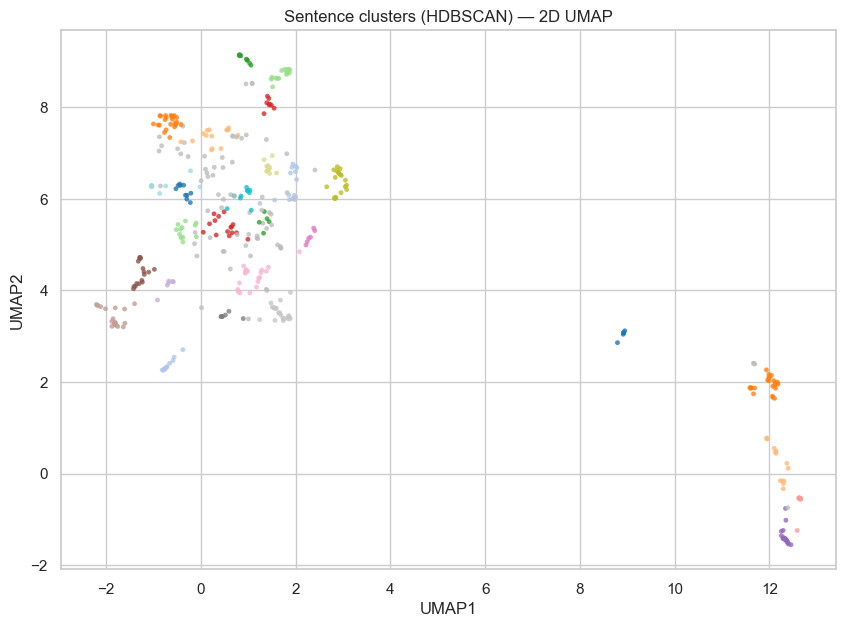

In [63]:
plt.figure(figsize=(10,7))
palette = sns.color_palette("tab20", n_colors=len(set(labels)))
# color mapping: -1 as gray
colors = [ "#bdbdbd" if lab == -1 else palette[lab % len(palette)] for lab in labels ]
plt.scatter(umap_emb_2d[:,0], umap_emb_2d[:,1], c=colors, s=12, linewidth=0, alpha=0.8)
plt.title("Sentence clusters (HDBSCAN) — 2D UMAP")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.show()


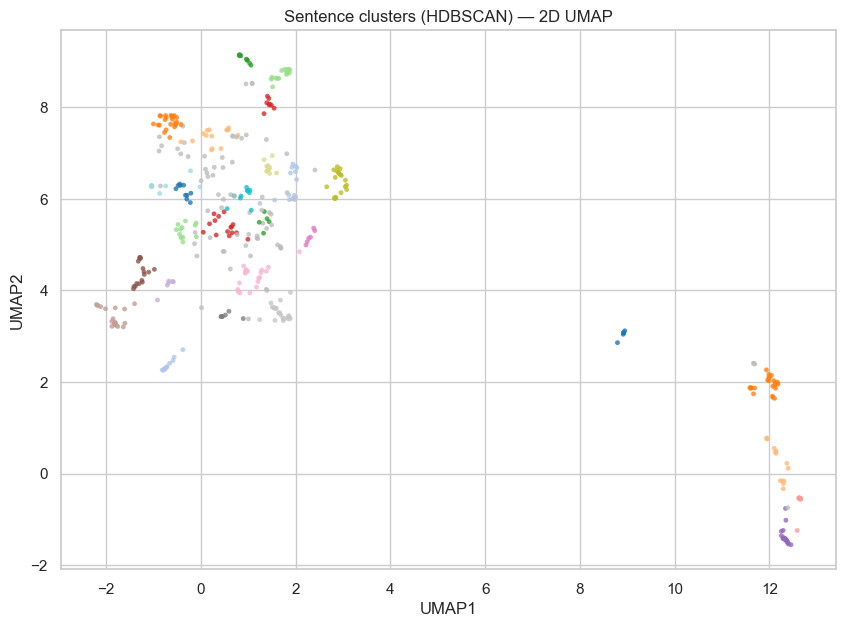

In [64]:
plt.figure(figsize=(10,7))
palette = sns.color_palette("tab20", n_colors=len(set(labels)))
# color mapping: -1 as gray
colors = [ "#bdbdbd" if lab == -1 else palette[lab % len(palette)] for lab in labels ]
plt.scatter(umap_emb_2d[:,0], umap_emb_2d[:,1], c=colors, s=12, linewidth=0, alpha=0.8)
plt.title("Sentence clusters (HDBSCAN) — 2D UMAP")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.show()
